# Chapter 17: Quantum Phase Estimation

Quantum phase estimation (QPE) solves the eigenvalue problems that pervade engineering -- structural vibrations, stability analysis, PCA, differential equations. Given a Hermitian matrix $A$, it maps $A$ to the unitary **Hamiltonian evolution operator** $U_A=e^{2\pi i A/\bar\lambda}$, which shares $A$'s eigenvectors but encodes each eigenvalue as a phase: $U_A|v^k\rangle=e^{2\pi i\theta_k}|v^k\rangle$ with $\theta_k=\lambda_k/\bar\lambda$. Phase kickback and the inverse QFT of Chapter 16 then decode $\theta_k$ into measurable bits.

This notebook builds QPE from scratch: the Hamiltonian operator, single-bit estimation via phase kickback, and multi-bit estimation using controlled $U_A^{2^r}$ powers followed by an inverse QFT. It shows that a superposition input returns the **whole eigenphase histogram** in one run -- no eigenvectors needed -- then covers Trotterization of $U_A$, Qiskit's built-in QPE routines, and a discrete-Laplacian example, noting candidly where QPE does and does not beat classical methods.

---

**Prerequisites:**
- See `Chapter02_QuantumSoftware.ipynb` for installation instructions

In [1]:
# Setup and imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import UnitaryGate
from qiskit.circuit.library import  HamiltonianGate
from qiskit.synthesis import LieTrotter, SuzukiTrotter
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import Statevector, Operator
from qiskit.quantum_info import SparsePauliOp
from Chapter17_QPE_functions import (myQPESingleBit, myQPEMultiBit,
    QiskitQPEWrapper, hamiltonianPhaseEstimationDemo, laplacian1D,
    laplacianEigenExact, laplacianEigenvector,
    estimateEigenvalueQPE)

print('Setup complete!')

Setup complete!


## Hamiltonian  *(Book §17.1, Example 17.2, Listing 17.1)*

Engineers' eigenvalue problems involve Hermitian $A=A^\dagger$, not unitaries. The bridge is $U_A=e^{2\pi i A/\bar\lambda}$ with $\bar\lambda$ larger than every eigenvalue: $U_A$ is unitary, keeps $A$'s eigenvectors, and turns each $\lambda_k$ into the phase $2\pi\lambda_k/\bar\lambda$. We build it with `HamiltonianGate` (which forms the full matrix exponential -- convenient but expensive) and act on an eigenvector $|v\rangle$. Qiskit uses $e^{-iAt}$ internally, so a **negative** $t$ appears in the code to match the $+i$ convention.

[[-0.25+0.4330127j  0.75+0.4330127j]
 [ 0.75+0.4330127j -0.25+0.4330127j]]


<IPython.core.display.Latex object>

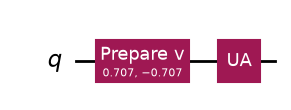

In [2]:
A = np.array([[2,-1],[-1,2]])
f = 0.5
lambdaUpper = 3
t = -2*np.pi*f/lambdaUpper #Note negative
U_A = HamiltonianGate(A, time=t,label = 'UA')
print(np.array(U_A.to_matrix()))
v = np.array([1/np.sqrt(2),-1/np.sqrt(2)])
circuit = QuantumCircuit(1)
circuit.prepare_state(Statevector(v) ,0,'Prepare v')
circuit.append(U_A, qargs=[0])
psi = Statevector(circuit)
display(psi.draw('latex'))
circuit.draw('mpl') 

## Control gate  *(Book §17.2.1, Figure 17.2)*

Single-bit QPE puts a control qubit in superposition with a Hadamard, then applies controlled-$U_A$. The eigenphase kicks back onto the control: $\tfrac1{\sqrt2}\big(|v\rangle|0\rangle+e^{2\pi i\theta}|v\rangle|1\rangle\big)$ -- the same phase-kickback mechanism seen in Chapter 12. Here we assemble that controlled gate on a two-qubit circuit.

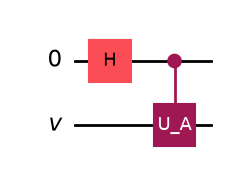

In [3]:
zeroQubit = QuantumRegister(1, '0')
vQubit = QuantumRegister(1, 'v')
circuit = QuantumCircuit(zeroQubit,vQubit) 
circuit.h(0)
UMatrix = 1/np.sqrt(2)*np.array([[1,1],[1j,-1j]]) 
U = UnitaryGate(UMatrix,'U_A')
UControl = U.control(1)
circuit.append(UControl,[0,1])
circuit.draw('mpl') 

## Probability Model  *(Book §17.2.1)*

A closing Hadamard converts the kicked-back phase into a measurable amplitude. Measuring the top qubit gives $P(0)=\cos^2(\pi\theta)$ and $P(1)=\sin^2(\pi\theta)$, so the outcome frequencies estimate $\theta$. This circuit adds the final Hadamard and measurement.

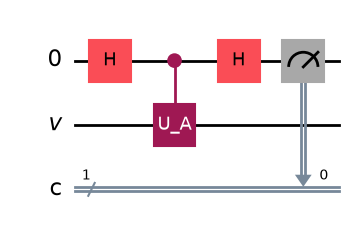

In [4]:
zeroQubit = QuantumRegister(1, '0')
vQubit = QuantumRegister(1, 'v')
cBit = ClassicalRegister(1, 'c')
circuit = QuantumCircuit(zeroQubit,vQubit,cBit) 
circuit.h(0)
UMatrix = 1/np.sqrt(2)*np.array([[1,1],[1j,-1j]]) 
U = UnitaryGate(UMatrix,'U_A')
UControl = U.control(1)
circuit.append(UControl,[0,1])
circuit.h(0)
circuit.measure([0], [0]) 
circuit.draw('mpl') 


### Example 1: an exact single bit  *(Book §17.2.1, Example 17.3, Listing 17.3)*

With $A=\mathrm{diag}(1,0.75)$, $\bar\lambda=2$ and $v=(1,0)^\top$, the eigenvalue is $\lambda=1$, so $\theta=1/2=(0.1)_2$ -- exactly one bit. We therefore expect $P(1)=1$: the measurement returns $1$ with certainty.

In [5]:
A = np.array([[1,0],[0,0.75]])
v = np.array([1,0])
lambdaUpper = 2

[thetaEstimates,probabilities] = myQPESingleBit(A,v,lambdaUpper,nShots=1000)
print("Theta estimates:", thetaEstimates)
print("Probabilities:", probabilities)

Counts: {'1': 1000}
Theta estimates: [0.5]
Probabilities: [1.]


### Example 2: an inexact single bit  *(Book §17.2.1, Example 17.4, Listing 17.4)*

Now $v=(0,1)^\top$ gives $\lambda=0.75$, so $\theta=0.375=(0.011)_2$ -- not representable in one bit. The single-bit circuit returns $0.5$ and $0$ with probabilities $\approx0.86$ and $0.14$; a weighted average gives $\tilde\theta\approx0.43$, motivating the multi-bit circuit next.

In [6]:
A = np.array([[1,0],[0,0.75]])
v = np.array([0,1])
lambdaUpper = 2

[thetaEstimates,probabilities] = myQPESingleBit(A,v,lambdaUpper,nShots=1000)
print("Theta estimates:", thetaEstimates)
print("Probabilities:", probabilities)

Counts: {'1': 861, '0': 139}
Theta estimates: [0.5 0. ]
Probabilities: [0.861 0.139]


## Multiple digit QPE  *(Book §17.2.2, Listing 17.5)*

To resolve $\theta$ to $m$ bits we use $m$ control qubits. The key identity is $U_A^{2^r}|v\rangle=e^{2\pi i(0.\theta_{m-r-1}\dots\theta_0)}|v\rangle$: each squaring of $U_A$ left-shifts the binary phase. Applying controlled $U_A^{2^r}$ for $r=0,\dots,m-1$ builds the product state of Equation (17.21); an **inverse QFT** then decodes it into $|\theta_{m-1}\dots\theta_0\rangle$, and measuring the $m$ qubits reads $\theta$. `myQPEMultiBit` implements this, returning $\theta$ estimates with probabilities; a weighted average $\tilde\theta=\sum_i P[i]\,\theta[i]$ collapses them to one number.

### Multibit Example 1: two bits  *(Book §17.2.2, Example 17.5, Listing 17.6)*

Repeating the $\theta=0.375$ case with $m=2$ bits, the weighted average sharpens to $\tilde\theta\approx0.37$, recovering the eigenvalue $\tilde\lambda=\tilde\theta\,\bar\lambda\approx0.74$.

In [7]:
A = np.array([[1,0],[0,0.75]])
v = np.array([0,1])
lambdaUpper = 2
nThetaBits = 2

[thetaEstimates,probabilities] = myQPEMultiBit(A,v,lambdaUpper,m = nThetaBits, nShots=1000)
thetaTilde = np.sum(thetaEstimates*probabilities)
print("Theta estimates:", thetaEstimates)
print("Probabilities:", probabilities)
print("thetaTilde: ", thetaTilde)

{'01': 450, '10': 405, '11': 73, '00': 72}
Theta estimates: [0.25 0.5  0.75 0.  ]
Probabilities: [0.45  0.405 0.073 0.072]
thetaTilde:  0.36975


### Multibit Example 2: three bits  *(Book §17.2.2, Example 17.6, Listing 17.7)*

With $m=3$ bits, $0.375=(0.011)_2$ is captured **exactly**: the estimate is $\tilde\theta=0.375$ with 100% certainty.

In [8]:
nThetaBits = 3

[thetaEstimates,probabilities] = myQPEMultiBit(A,v,lambdaUpper,m = nThetaBits, nShots=1000)
thetaTilde = np.sum(thetaEstimates*probabilities)
print("Theta estimates:", thetaEstimates)
print("Probabilities:", probabilities)
print("thetaTilde: ", thetaTilde)

{'011': 1000}
Theta estimates: [0.375]
Probabilities: [1.]
thetaTilde:  0.375


### Multibit Example 3: extra bits do not hurt  *(Book §17.2.2, Example 17.7, Listing 17.8)*

Using $m=5$ bits still returns $\tilde\theta=0.375$ with certainty -- once $\theta$ is exactly representable, adding precision qubits leaves the estimate unchanged.

In [9]:
nThetaBits = 5

[thetaEstimates,probabilities] = myQPEMultiBit(A,v,lambdaUpper,m = nThetaBits, nShots=1000)
thetaTilde = np.sum(thetaEstimates*probabilities)
print("Theta estimates:", thetaEstimates)
print("Probabilities:", probabilities)
print("thetaTilde: ", thetaTilde)

{'01100': 1000}
Theta estimates: [0.375]
Probabilities: [1.]
thetaTilde:  0.375


## Qiskit QPE Wrapper  *(Book §17.5, Listing 17.13)*

Having built QPE by hand, we now wrap Qiskit's library `phase_estimation`, which assembles the QPE circuit around a unitary we supply. Its inverse QFT reverses the output qubit order, so the measurement writes phase qubit $i$ into classical bit $m-1-i$ to make the decoding $\theta=\mathrm{int(key,2)}/2^m$ agree with `myQPEMultiBit`; on the matrices of Table 3.1 the two routines return identical estimates. These examples also exercise **superposition inputs** (Book §17.3): one QPE run on $|v\rangle=\sum_k a_k|v^k\rangle$ returns each eigenphase $\theta_k$ with probability $|a_k|^2$.

### Wrapper Example 1  *(Book §17.5, §17.3, Example 17.8)*

A first run on the diagonal $A=\mathrm{diag}(1,0.75)$ with $\bar\lambda=2$, selecting an eigenvector to recover its eigenphase through the Qiskit wrapper.

In [10]:
A = np.array([[1,0],[0,0.75]])
v0 = np.array([0,1])          # eigenvector with lambda = 0.75  ->  theta = 0.375
v1 = np.array([1,0])          # eigenvector with lambda = 1.0   ->  theta = 0.5
a = [1,0]                     # select v0
v = a[0]*v0 + a[1]*v1
lambdaUpper = 2
m = 3                         # 3 bits capture theta = 0.375 = (0.011)_2 exactly

[thetaEstimates, P] = QiskitQPEWrapper(A, v, lambdaUpper, m)
thetaTilde = np.sum(thetaEstimates*P)
print("theta estimates:", thetaEstimates)
print("probabilities:  ", P)
print("thetaTilde:      ", thetaTilde, " (exact 0.375)")
print("eigenvalueTilde: ", thetaTilde*lambdaUpper, " (exact 0.75)")

theta estimates: [0.375]
probabilities:   [1.]
thetaTilde:       0.375  (exact 0.375)
eigenvalueTilde:  0.75  (exact 0.75)


### Wrapper Example 2  *(Book §17.5, §17.3, Example 17.9)*

The same wrapper on $A=\begin{bmatrix}2&-1\\-1&2\end{bmatrix}$ (eigenvalues $1,3$) with $\bar\lambda=6$ and $m=4$ precision qubits. When an eigenphase is not an exact $m$-bit fraction, the estimate spreads across neighbouring bins (spectral leakage).

In [11]:
A = np.array([[2,-1],[-1,2]])
v0 = np.array([1/np.sqrt(2), 1/np.sqrt(2)])   # eigenvector with lambda = 1
v1 = np.array([1/np.sqrt(2),-1/np.sqrt(2)])   # eigenvector with lambda = 3
a = [1,0]                                      # select v0
v = a[0]*v0 + a[1]*v1
lambdaUpper = 6
m = 4                                          # theta = 1/6 is NOT an exact 4-bit fraction

[thetaEstimates, P] = QiskitQPEWrapper(A, v, lambdaUpper, m)
thetaTilde = np.sum(thetaEstimates*P)
print("theta estimates:", np.round(thetaEstimates, 4))
print("probabilities:  ", np.round(P, 4))
print("thetaTilde:      ", thetaTilde, " (exact 1/6 = 0.1667)")
print("eigenvalueTilde: ", thetaTilde*lambdaUpper, " (exact 1.0)")
# The estimate spreads across neighbouring bins: spectral leakage.

theta estimates: [0.1875 0.125  0.25   0.0625 0.3125 0.     0.375  0.75   0.4375 0.625
 0.9375 0.5625 0.875  0.6875 0.8125 0.5   ]
probabilities:   [0.683 0.175 0.046 0.025 0.015 0.009 0.008 0.007 0.006 0.006 0.005 0.005
 0.004 0.003 0.002 0.001]
thetaTilde:       0.19750000000000004  (exact 1/6 = 0.1667)
eigenvalueTilde:  1.1850000000000003  (exact 1.0)


### Wrapper Example 3: a $4\times4$ system  *(Book §17.5, §17.3)*

A $4\times4$ Hermitian matrix (eigenvalues $0.5,1,1,1.5$); we select an eigenvector, run QPE and recover the eigenphase together with the eigenvalue $\tilde\lambda=\tilde\theta\,\bar\lambda$.

In [12]:
A = np.array([[1,0,0,-0.5],[0,1,0,0],[0,0,1,0],[-0.5,0,0,1]])
v0 = np.array([1/np.sqrt(2),0,0,1/np.sqrt(2)])   # lambda = 0.5
v1 = np.array([0,1,0,0])                          # lambda = 1
v2 = np.array([0,0,1,0])                          # lambda = 1
v3 = np.array([1/np.sqrt(2),0,0,-1/np.sqrt(2)])   # lambda = 1.5
a = [0,0,1,0]                                      # select v2 (lambda = 1)
v = a[0]*v0 + a[1]*v1 + a[2]*v2 + a[3]*v3
lambdaUpper = 3
m = 5                          # theta = 1/3 = 0.010101..._2 needs several bits

[thetaEstimates, P] = QiskitQPEWrapper(A, v, lambdaUpper, m)
thetaTilde = np.sum(thetaEstimates*P)
print("thetaEstimates:", np.round(thetaEstimates, 4))
print("probabilities: ", np.round(P, 4))
print("thetaTilde:    ", thetaTilde, " (exact 1/3 = 0.3333)")
print("EigenvalueTilde:", thetaTilde*lambdaUpper, " (exact 1.0)")

thetaEstimates: [0.3438 0.3125 0.2812 0.375  0.25   0.4062 0.4375 0.2188 0.9688 0.4688
 0.7812 0.1875 0.5    0.5312 0.5938 0.1562 0.625  0.0312 0.7188 0.
 0.6875 0.125  0.5625 0.0938 0.6562 0.9062 0.9375 0.0625]
probabilities:  [0.694 0.145 0.039 0.026 0.017 0.014 0.01  0.006 0.005 0.004 0.004 0.004
 0.004 0.003 0.003 0.003 0.003 0.002 0.002 0.002 0.002 0.002 0.001 0.001
 0.001 0.001 0.001 0.001]
thetaTilde:     0.344875  (exact 1/3 = 0.3333)
EigenvalueTilde: 1.034625  (exact 1.0)


### QPE on a $4\times4$ Laplacian with a random input  *(Book §17.3)*

Here $A=\mathrm{tridiag}(-1,2,-1)$ on four nodes and $|v\rangle$ is a **random** normalized vector. Because QPE is linear, one run returns every eigenphase excited by $|v\rangle$ -- we need not know the eigenvectors in advance.

In [13]:
m = 3
A = np.array([[2,-1,0,0],[-1,2,-1,0],[0,-1,2,-1],[0,0,-1,2]])
v = np.random.rand(4)
v = v/np.linalg.norm(v)         # any normalized vector; eigenvectors need not be known
lambdaUpper = 4

[thetaEstimates, P] = myQPEMultiBit(A, v, lambdaUpper, m)
print("theta estimates:  ", np.round(thetaEstimates, 3))
print("probabilities:    ", np.round(P, 3))
print("recovered lambdas:", np.round(thetaEstimates*lambdaUpper, 3))
print("exact spectrum:   ", np.round(np.linalg.eigvalsh(A), 3))

{'001': 731, '000': 86, '111': 55, '011': 14, '010': 33, '101': 57, '110': 15, '100': 9}
theta estimates:   [0.125 0.    0.625 0.875 0.25  0.75  0.375 0.5  ]
probabilities:     [0.731 0.086 0.057 0.055 0.033 0.015 0.014 0.009]
recovered lambdas: [0.5 0.  2.5 3.5 1.  3.  1.5 2. ]
exact spectrum:    [0.382 1.382 2.618 3.618]


## Trotterization error  *(Book §17.4, Example 17.10, Listing 17.12)*

Forming $U_A$ as a full exponential scales poorly. Instead we split $A=\sum_j\alpha_j P_j$ into Pauli terms whose individual exponentials are easy gates, and approximate $e^{iAt}\approx\big(\prod_j e^{iA_j t/r}\big)^r$. For $A=2Z-0.5X$ (with $Z,X$ non-commuting) we compare the first-order Lie–Trotter error $O(t^2/r)$ against the second-order Suzuki–Trotter error $O(t^3/r^2)$: doubling $r$ halves the first-order error but quarters the second-order one.

In [14]:
# Pauli matrices
Z = np.array([[1, 0], [0, -1]])
X = np.array([[0, 1], [1, 0]])
 
# A = 2Z - 0.5X
A = 2*Z - 0.5*X
A1 = 2*Z
A2 = -0.5*X
 
lambdaUpper = 5
t = 2*np.pi/lambdaUpper
 
# Exact Hamiltonian
U_exact = expm(1j*A*t)
 
# Trotter convergence (first-order only)
for r in [1, 2, 5, 10, 50, 100]:
    dt = t / r
    step1 = expm(1j * A1 * dt) @ expm(1j * A2 * dt)
    U_trotter1 = np.linalg.matrix_power(step1, r)
    err1 = np.linalg.norm(U_exact - U_trotter1)
    print(f"r={r:3d}: 1st-order err={err1:.6f}")

# Trotter convergence (second-order only)
for r in [1, 2, 5, 10, 50, 100]:
    dt = t / r
    step2 = expm(1j * A1 * dt / 2) @ expm(1j * A2 * dt) @ expm(1j * A1 * dt / 2)
    U_trotter2 = np.linalg.matrix_power(step2, r)
    err2 = np.linalg.norm(U_exact - U_trotter2)
    print(f"r={r:3d}: 2nd-order err={err2:.6f}")

r=  1: 1st-order err=1.022180
r=  2: 1st-order err=0.268470
r=  5: 1st-order err=0.092678
r= 10: 1st-order err=0.045427
r= 50: 1st-order err=0.009028
r=100: 1st-order err=0.004513
r=  1: 2nd-order err=0.710502
r=  2: 2nd-order err=0.091288
r=  5: 2nd-order err=0.012592
r= 10: 2nd-order err=0.003087
r= 50: 2nd-order err=0.000123
r=100: 2nd-order err=0.000031


### Qiskit Trotterization  *(Book §17.4)*

Qiskit realizes the same idea through `PauliEvolutionGate` with `LieTrotter` or `SuzukiTrotter` synthesis. We compare the Trotterized evolution of $A=2Z-0.5X$ against the exact Hamiltonian as the step count and Trotter order increase.

In [15]:
# A = 2Z - 0.5X
A = np.array([[2, -0.5], [-0.5, -2]])
lambdaUpper = 5
t = 2*np.pi/lambdaUpper

# Exact Hamiltonian
U_exact = expm(1j*A*t)

# Pauli decomposition
H_pauli = SparsePauliOp.from_list([('Z', 2.0), ('X', -0.5)])

# First-order Trotter
for r in [1, 2, 5, 10, 50]:
    synth = LieTrotter(reps=r)
    evo = PauliEvolutionGate(H_pauli, time=-t, synthesis=synth)
    qc = QuantumCircuit(1)
    qc.append(evo, [0])
    U_trot = np.array(Operator(qc.decompose()))
    print(f"r={r:2d}: 1st-order err = "
          f"{np.linalg.norm(U_exact - U_trot):.6f}")

# Second-order Trotter
for r in [1, 2, 5, 10, 50]:
    synth = SuzukiTrotter(order=2, reps=r)
    evo = PauliEvolutionGate(H_pauli, time=-t, synthesis=synth)
    qc = QuantumCircuit(1)
    qc.append(evo, [0])
    U_trot = np.array(Operator(qc.decompose()))
    print(f"r={r:2d}: 2nd-order err = "
          f"{np.linalg.norm(U_exact - U_trot):.6f}")

r= 1: 1st-order err = 1.022180
r= 2: 1st-order err = 0.268470
r= 5: 1st-order err = 0.092678
r=10: 1st-order err = 0.045427
r=50: 1st-order err = 0.009028
r= 1: 2nd-order err = 0.710502
r= 2: 2nd-order err = 0.091288
r= 5: 2nd-order err = 0.012592
r=10: 2nd-order err = 0.003087
r=50: 2nd-order err = 0.000123


## Qiskit `HamiltonianPhaseEstimation`  *(Book §17.5, Listing 17.14)*
Hand Qiskit the **Hermitian matrix A itself**; it scales and Trotterizes internally. The `evolution` argument is the Trotter knob -- the **default is a single first-order step**, the least accurate case. For $A=2Z-0.5X$ (exact top eigenvalue $2.0616$) the default returns a biased $1.9219$, while `SuzukiTrotter(order=2, reps=8)` recovers $2.0625$.

In [16]:
# HamiltonianPhaseEstimation on A = 2Z - 0.5X (exact top eigenvalue 2.0616).
# The default first-order/1-step evolution is biased; a 2nd-order Trotter
# (or more reps) removes the error.  Requires the qiskit-algorithms package.
from qiskit.synthesis import LieTrotter, SuzukiTrotter

A = np.array([[2., -0.5], [-0.5, -2.]])          # = 2Z - 0.5X
w, V = np.linalg.eigh(A); vTop = V[:, int(np.argmax(w))]

for evo, label in [(None,                        'default (1st-order, 1 step)'),
                   (LieTrotter(reps=20),          'LieTrotter reps=20'),
                   (SuzukiTrotter(order=2, reps=8),'SuzukiTrotter order=2 reps=8')]:
    res = hamiltonianPhaseEstimationDemo(A, vTop, bound=3.0, m=8, evolution=evo)
    print(f'{label:32s} -> {res.most_likely_eigenvalue.real:+.4f} (exact {w.max():.4f})')

default (1st-order, 1 step)      -> +1.9219 (exact 2.0616)
LieTrotter reps=20               -> +2.0625 (exact 2.0616)
SuzukiTrotter order=2 reps=8     -> +2.0625 (exact 2.0616)


## Example: a discrete Laplacian  *(Book §17.6, Example 17.11, Listing 17.15)*
QPE applies unchanged to a matrix engineers recognize -- the 1D Laplacian, whose spectrum is known in closed form (used here only to check). The fundamental is the smallest eigenvalue, hence the smallest phase and the hardest to resolve. With $\bar\lambda=4$ and $m=8$, the dominant bin gives $\tilde\lambda_0=0.375$ against the exact $0.382$.

In [17]:
# Fundamental mode of the 1D Dirichlet Laplacian via QPE.
N = 4                                   # N = 2**n
A = laplacian1D(N)                      # tridiag(-1, 2, -1)
print('exact spectrum:', np.round(laplacianEigenExact(N), 4))

v0 = laplacianEigenvector(N, 0)         # analytic fundamental mode (sine)
peak, weighted = estimateEigenvalueQPE(A, v0, lambdaUpper=4.0, m=8)
print(f'fundamental via QPE: peak={peak:.4f}  weighted={weighted:.4f}  '
      f'exact={laplacianEigenExact(N)[0]:.4f}')

exact spectrum: [0.382 1.382 2.618 3.618]
fundamental via QPE: peak=0.3750  weighted=0.3987  exact=0.3820


### One QPE run reads the whole spectrum  *(Book §17.6, Listing 17.16)*
Feed an equal-weight superposition of all four modes: a single QPE run returns every eigenvalue at once, each with weight $|b^k|^2\approx0.25$. An $N$-dim system has at most $N$ eigenvalues, so we keep the $N$ most probable bins and take `min` for $\lambda^0$ (the bound HHL needs). But a faint real eigenvalue is indistinguishable from spectral leakage, so no fixed cutoff is principled -- the same reason HHL's lower bound is only approximate.

In [18]:
# Equal-weight superposition of all modes -> one QPE run reads the whole spectrum.
b = sum(laplacianEigenvector(N, k) for k in range(N))
b = b / np.linalg.norm(b)
theta, P = myQPEMultiBit(A, b, lambdaUpper=4.0, m=8)
topN = theta[np.argsort(P)[-N:]]            # an N-dim system has <= N eigenvalues
print('recovered lambda:', np.round(np.sort(topN * 4.0), 3))
print('exact spectrum  :', np.round(laplacianEigenExact(N), 3))
print('lambda_min =', round(min(topN) * 4.0, 4))

{'01010101': 2, '00011001': 92, '00010101': 5, '01011001': 84, '00101101': 1, '11001100': 2, '00011000': 110, '11001111': 1, '11100100': 1, '10101000': 134, '11011101': 1, '11100111': 65, '01011000': 111, '00010100': 2, '11100010': 1, '10100100': 3, '11101000': 132, '00010111': 10, '10100111': 76, '10101100': 2, '11101101': 1, '11010111': 1, '01010111': 9, '10010100': 1, '11100101': 4, '00000000': 1, '10101001': 17, '01010110': 7, '10100101': 6, '11101001': 12, '01010011': 3, '10111001': 1, '01100101': 2, '11101011': 3, '00100110': 1, '11010000': 1, '11101100': 1, '01101000': 1, '01011010': 13, '10101010': 5, '01001011': 1, '11101010': 12, '10101101': 2, '00011011': 3, '00010011': 1, '00011100': 2, '10100110': 12, '00010110': 3, '00011010': 8, '10100011': 2, '01011111': 1, '11100110': 7, '10101011': 1, '00011101': 1, '11111010': 1, '01011011': 3, '00010010': 1, '01001101': 1, '00100010': 2, '11100011': 3, '00110001': 1, '11101111': 1, '01010000': 1, '10110000': 1, '10011000': 1, '10001